In [1]:
import pandas as pd

df = pd.read_csv("student_marks.csv")

print("Total students:", len(df))
df.head()

Total students: 30


,Name,Python,DBMS,Maths
0,Aman,85,78,90
1,Riya,92,88,95
2,Vikram,78,82,75
3,Priya,65,70,60
4,Rahul,45,50,55


In [2]:
# Calculate total marks
df["Total"] = df[["Python", "DBMS", "Maths"]].sum(axis=1)


In [3]:
# Calculate average marks
df["Average"] = (df["Total"] / 3).round(2)

In [4]:
# Calculate Pass/Fail
df["Result"] = df[["Python", "DBMS", "Maths"]].apply(
    lambda row: "Pass" if all(row >= 40) else "Fail",
    axis=1)

In [5]:
df

,Name,Python,DBMS,Maths,Total,Average,Result
0,Aman,85,78,90,253,84.33,Pass
1,Riya,92,88,95,275,91.67,Pass
2,Vikram,78,82,75,235,78.33,Pass
3,Priya,65,70,60,195,65.00,Pass
4,Rahul,45,50,55,150,50.00,Pass
5,Neha,88,91,84,263,87.67,Pass
6,Arjun,73,69,77,219,73.00,Pass
7,Sneha,96,94,91,281,93.67,Pass
8,Karan,54,61,58,173,57.67,Pass
9,Ananya,81,85,88,254,84.67,Pass


In [6]:
print("Total Students:", len(df))
print("Class Average:", round(df["Average"].mean(), 2))
print("Highest Total:", df["Total"].max())
print("Lowest Total:", df["Total"].min())

pass_count = (df["Result"] == "Pass").sum()
fail_count = (df["Result"] == "Fail").sum()

print("Students Passed:", pass_count)
print("Students Failed:", fail_count)
print("Pass Percentage:", round(pass_count / len(df) * 100, 2), "%")

Total Students: 30
Class Average: 75.38
Highest Total: 294
Lowest Total: 133
Students Passed: 30
Students Failed: 0
Pass Percentage: 100.0 %


In [7]:
%matplotlib inline

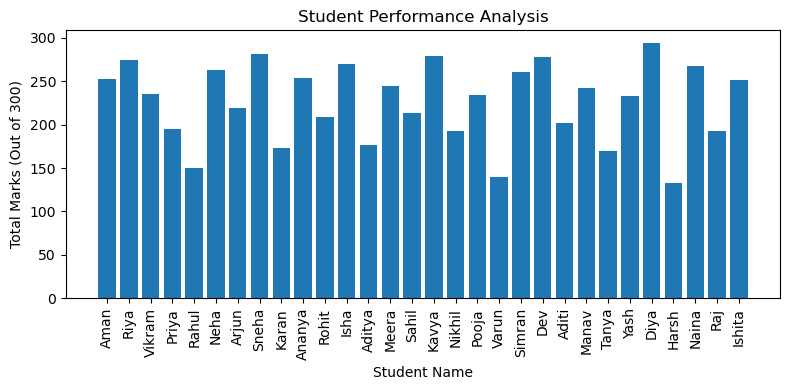

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.bar(df["Name"], df["Total"])

plt.xlabel("Student Name")
plt.ylabel("Total Marks (Out of 300)")
plt.title("Student Performance Analysis")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [10]:
import os

print(os.getcwd())

C:\Users\kesha\python3\mini project


In [11]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Student Marks Analyzer",
    page_icon="📊",
    layout="wide"
)

st.title("Student Marks Analyzer")
st.write("Analyze student performance using marks data.")

uploaded_file = st.file_uploader(
    "Upload student CSV file",
    type=["csv"]
)

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
else:
    st.info("Upload a CSV file to begin.")
    st.stop()

subjects = ["Python", "DBMS", "Maths"]

if not all(col in df.columns for col in ["Name"] + subjects):
    st.error("CSV must contain Name, Python, DBMS, and Maths columns.")
    st.stop()

for subject in subjects:
    df[subject] = pd.to_numeric(df[subject], errors="coerce")

df = df.dropna(subset=subjects)

if df.empty:
    st.error("No valid student marks found.")
    st.stop()

df["Total"] = df[subjects].sum(axis=1)
df["Average"] = (df["Total"] / len(subjects)).round(2)

df["Result"] = df[subjects].ge(40).all(axis=1).map(
    {True: "Pass", False: "Fail"}
)

st.subheader("Class Statistics")

col1, col2, col3, col4 = st.columns(4)

col1.metric("Total Students", len(df))
col2.metric("Class Average", round(df["Average"].mean(), 2))
col3.metric("Highest Total", df["Total"].max())
col4.metric("Pass Percentage", 
            f"{(df['Result'].eq('Pass').mean() * 100):.1f}%")

st.subheader("Student Results")
st.dataframe(df, use_container_width=True)

st.subheader("Student Performance Chart")

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df["Name"], df["Total"])
ax.set_xlabel("Student Name")
ax.set_ylabel("Total Marks (Out of 300)")
ax.set_title("Total Marks by Student")
plt.xticks(rotation=90)
fig.tight_layout()

st.pyplot(fig)
plt.close(fig)

st.subheader("Subject-wise Comparison")

st.bar_chart(df.set_index("Name")[subjects])

csv = df.to_csv(index=False).encode("utf-8")

st.download_button(
    "Download Analyzed Results",
    data=csv,
    file_name="analyzed_student_results.csv",
    mime="text/csv"
)

Overwriting app.py


In [ ]:
!streamlit run app.py